In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Bibliotecas Necessarias **

In [2]:
print("Numpy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)

Numpy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


1. Baixe os dados disponibilizados na plataforma Kaggle sobre dados sócio-econômicos e de saúde que determinam oíndice de desenvolvimento de um país. Esses dados estão disponibilizados através do link:
https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

Instalar a library do Kaggle e kagglehub

In [3]:
## install kaggle

!pip install kaggle

In [4]:

## instalar kagglehub e importar

!pip install kagglehub
import kagglehub


Importar o dataframe unsupervised-learning-on-country-data do kaggle

In [5]:
## abrindo o arquivo diretamente do kaggle

## file_path = 'https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data'

pais_path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")



100%|██████████| 5.21k/5.21k [00:00<00:00, 7.99MB/s]

Extracting files...


In [6]:
print("Path to dataset files:", pais_path)

Path to dataset files: /root/.cache/kagglehub/datasets/rohan0301/unsupervised-learning-on-country-data/versions/2


In [7]:
!ls $pais_path -lh


total 16K
-rw-r--r-- 1 root root 9.1K Nov 10 15:42 Country-data.csv
-rw-r--r-- 1 root root  808 Nov 10 15:42 data-dictionary.csv


criar um dataframe local de nome df_ctrdata

In [8]:
## criar um dataframe local csv com base no que foi baixado do Kaggle

df_ctrdata = pd.read_csv(f"{pais_path}/Country-data.csv")
df_ctrdata.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Verificar o nome das colunas do dataframe

In [9]:
## verifica o nome das colunas do dataframe

df_ctrdata.columns


Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [10]:
## verifica quantos paises existem no dataframe

df_ctrdata['country'].nunique()

167

Criacao dos graficos

In [11]:
## criacao do grafico de variaveis socioeconomicas e de saude

df_ctrdata.values


array([['Afghanistan', 90.2, 10.0, ..., 56.2, 5.82, 553],
       ['Albania', 16.6, 28.0, ..., 76.3, 1.65, 4090],
       ['Algeria', 27.3, 38.4, ..., 76.5, 2.89, 4460],
       ...,
       ['Vietnam', 23.3, 72.0, ..., 73.1, 1.95, 1310],
       ['Yemen', 56.3, 30.0, ..., 67.5, 4.67, 1310],
       ['Zambia', 83.1, 37.0, ..., 52.0, 5.4, 1460]], dtype=object)

In [12]:
## Criar dataset numerico retirando a coluna country

df = pd.read_csv(f"{pais_path}/Country-data.csv")

df_num = df.drop(columns=['country'])
df_num.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Fazer o grafico da faixa dinamica

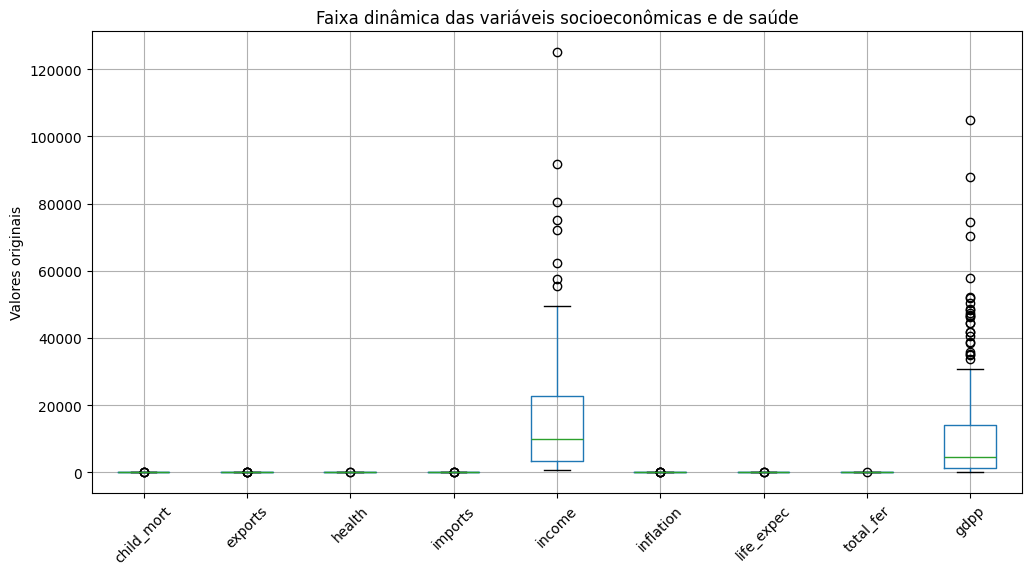

In [13]:
plt.figure(figsize=(12,6))
df_num.boxplot(rot=45)
plt.title("Faixa dinâmica das variáveis socioeconômicas e de saúde")
plt.ylabel("Valores originais")
plt.show()

Analise: algumas variaveis (ex,: income, GDP) tem valores muito maiores que outros. o que faz com que a analise de clusterizacao fique desbalanceada

Comparando-se as escalas com histograma

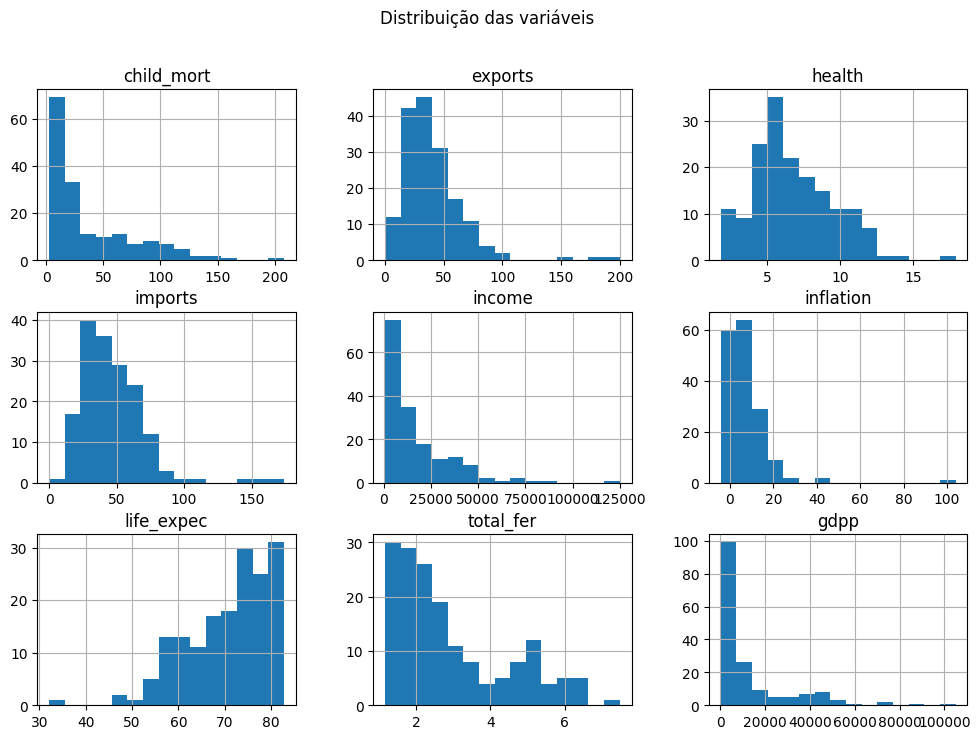

In [14]:
## construir o grafico histograma das features

df_num.hist(figsize=(12,8), bins=15)
plt.suptitle("Distribuição das variáveis")
plt.show()

Analise: as variáveis apresentam escalas bem distintas (por exemplo, PIB per capita em milhares e taxa de mortalidade infantil em dezenas).

Esse fato acarreta que em algoritmos de clusterização como K-Means, variáveis com valores maiores dominem a distância.

Assim, antes da clusterização se torna mandatorio normalizar/padronizar os dados — por exemplo, usando StandardScaler ou MinMaxScaler do scikit-learn.

4.Realizando o pré-processamento adequado dos dados.


Normalizacao

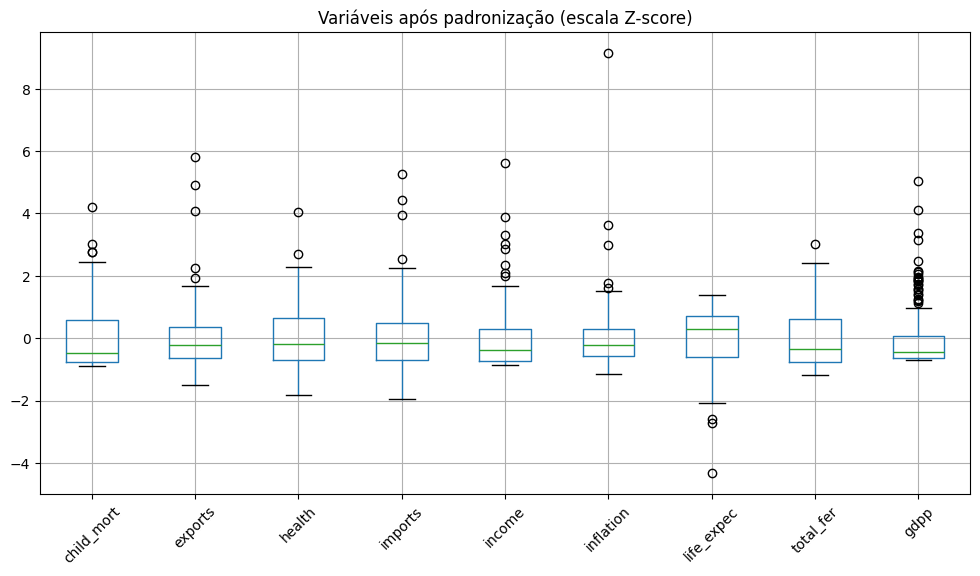

In [15]:
## Utilizando-se o sklearn

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns)

# Visualizar novamente a faixa dinâmica depois da normalização
plt.figure(figsize=(12,6))
df_scaled.boxplot(rot=45)
plt.title("Variáveis após padronização (escala Z-score)")
plt.show()

Agora fazer o pre processamento dos dados usando o StandardScaler

Formato original: (167, 9)

Valores ausentes por coluna:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


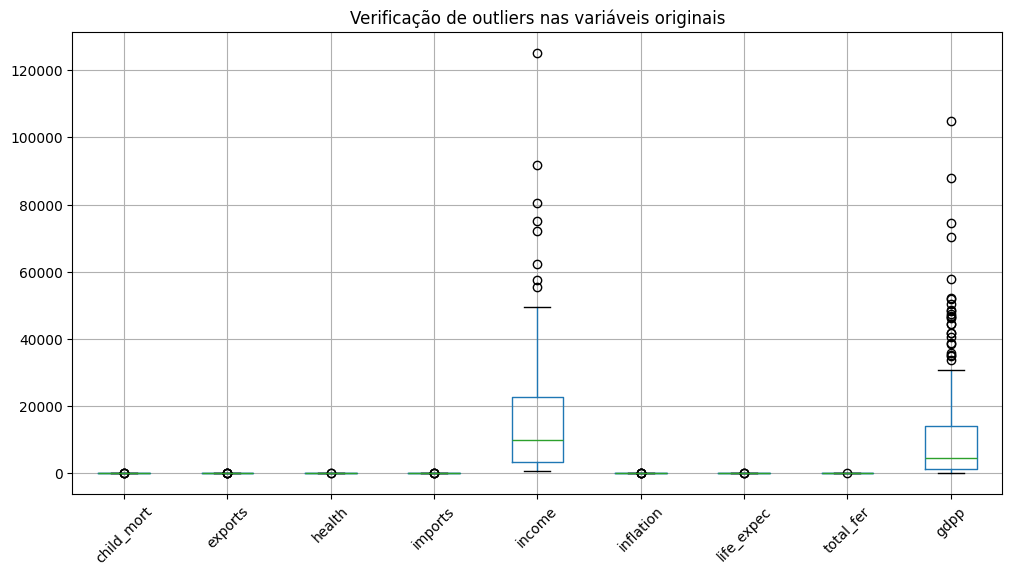


Observação:
Podem existir outliers naturais (como países muito ricos ou pobres),
mas não há dados ausentes. Vamos apenas padronizar as escalas.



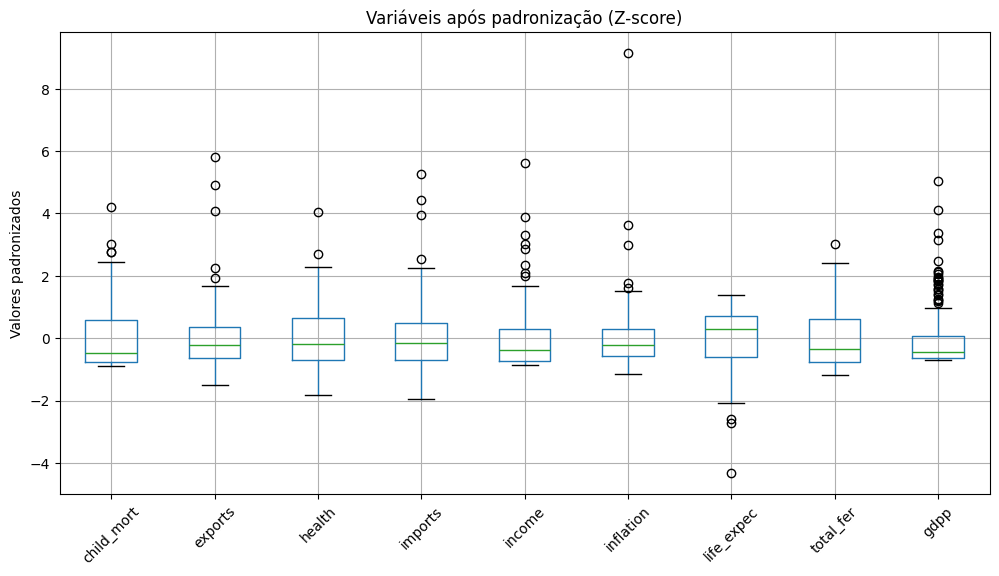


Resumo estatístico das variáveis após normalização:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.83,-1.94,-0.86,-1.14,-4.34,-1.19,-0.70
25%,-0.75,-0.63,-0.69,-0.69,-0.72,-0.57,-0.59,-0.76,-0.64
50%,-0.47,-0.22,-0.18,-0.15,-0.37,-0.23,0.29,-0.36,-0.45
75%,0.59,0.37,0.65,0.49,0.29,0.28,0.70,0.62,0.06
max,4.22,5.81,4.05,5.27,5.61,9.13,1.38,3.01,5.04



✅ PRÉ-PROCESSAMENTO CONCLUÍDO:
- Todas as variáveis agora estão na mesma escala (média = 0, desvio padrão = 1).
- O dataset está pronto para algoritmos de clusterização (K-Means, Hierárquico, DBSCAN etc.).



In [16]:
## PRÉ-PROCESSAMENTO DOS DADOS

from sklearn.preprocessing import StandardScaler

## Reutilizando o df e df_num da etapa anterior
print("Formato original:", df_num.shape)

## Etapa 1 - Verificar valores ausentes
print("\nValores ausentes por coluna:")
print(df_num.isnull().sum())

## Etapa 2 - Detecção de outliers com boxplot
plt.figure(figsize=(12,6))
df_num.boxplot(rot=45)
plt.title("Verificação de outliers nas variáveis originais")
plt.show()

print("""
Observação:
Podem existir outliers naturais (como países muito ricos ou pobres),
mas não há dados ausentes. Vamos apenas padronizar as escalas.
""")


## Etapa 3- Padronização dos dados (Z-score)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns)

## Etapa 4 - Verificar distribuição após a padronização
plt.figure(figsize=(12,6))
df_scaled.boxplot(rot=45)
plt.title("Variáveis após padronização (Z-score)")
plt.ylabel("Valores padronizados")
plt.show()

## Etapa 5 - Estatísticas resumidas
print("\nResumo estatístico das variáveis após normalização:")
display(df_scaled.describe().round(2))

## Etapa 6 - Verificação final
print("""
✅ PRÉ-PROCESSAMENTO CONCLUÍDO:
- Todas as variáveis agora estão na mesma escala (média = 0, desvio padrão = 1).
- O dataset está pronto para algoritmos de clusterização (K-Means, Hierárquico, DBSCAN etc.).
""")


Explicacao do passo a passo?
1. Verifica valores ausentes, uma vez que a clusterizacao nao aceita valores vazios
2. Analisa outliers porque eles podem distorcer as distancias
3. padroniza variaveis, aplicando-se StandardScaler, para deixar todas as variaveis na mesma escala
4. Compara antes e depois: todas as variaveis centradas em torno de 0
5. Resume estatisticas: confirma a padronizacao (media para 0, desvio para 1)

O Dataset resultante chama-se df.scaled, contendo apenas valores numericos padronizados, e pode ser usado em: K-Means, DBSCAN, bem como PCA (reducao de dimensionamento, e AgglomerativeClustering

**3. Clusterizacao**

Para os dados pré-processados da etapa anterior você irá:
1. Realizar o agrupamento dos países em 3 grupos distintos. Para tal, use:
a. K-Médias
b. Clusterização Hierárquica

2. Para os resultados, do K-Médias:
a. Interprete cada um dos clusters obtidos citando:
i. Qual a distribuição das dimensões em cada grupo
ii. O país, de acordo com o algoritmo, melhor representa o seu agrupamento. Justifique

3. Para os resultados da Clusterização Hierárquica, apresente o dendograma e interprete os resultados

4. Compare os dois resultados, aponte as semelhanças e diferenças e interprete.

Etapa 1 - Clusterizando para 3 grupos usando K-Medias

Número de países por cluster:
Cluster
0    86
1    36
2    45
Name: count, dtype: int64


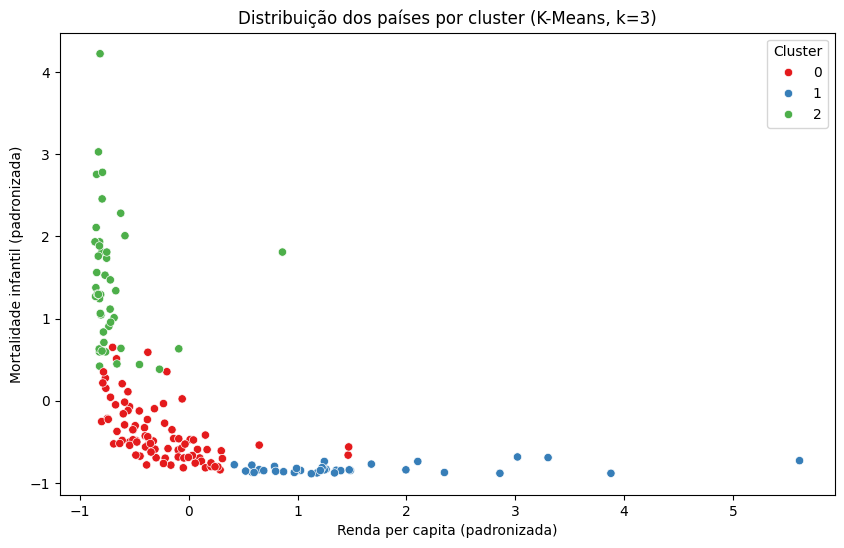


🌍 Países no Cluster 0:


,country
1,Albania
2,Algeria
4,Antigua and Barbuda
5,Argentina
6,Armenia
9,Azerbaijan
10,Bahamas
12,Bangladesh
13,Barbados
14,Belarus



🌍 Países no Cluster 1:


,country
7,Australia
8,Austria
11,Bahrain
15,Belgium
23,Brunei
29,Canada
42,Cyprus
43,Czech Republic
44,Denmark
53,Finland



🌍 Países no Cluster 2:


,country
0,Afghanistan
3,Angola
17,Benin
25,Burkina Faso
26,Burundi
28,Cameroon
31,Central African Republic
32,Chad
36,Comoros
37,"Congo, Dem. Rep."



Centroides dos clusters (valores padronizados):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,-0.393282,-0.030584,-0.206179,0.019562,-0.250930,-0.005783,0.226762,-0.402579,-0.355832
1,-0.827449,0.645080,0.727411,0.190639,1.484243,-0.484921,1.079579,-0.791877,1.615995
2,1.413564,-0.457615,-0.187898,-0.189897,-0.707839,0.398989,-1.297031,1.402874,-0.612761


In [17]:
# ============================================
# ETAPA 5 - CLUSTERIZAÇÃO COM K-MEANS (3 grupos)
# ============================================

from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ - Definir e treinar o modelo com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)

# 2️⃣ - Adicionar o número do cluster ao dataset original
df['Cluster'] = kmeans.labels_

# 3️⃣ - Contagem de países por cluster
print("Número de países por cluster:")
print(df['Cluster'].value_counts().sort_index())

# 4️⃣ - Visualização: gráfico 2D usando duas variáveis
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df_scaled['income'],
    y=df_scaled['child_mort'],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title("Distribuição dos países por cluster (K-Means, k=3)")
plt.xlabel("Renda per capita (padronizada)")
plt.ylabel("Mortalidade infantil (padronizada)")
plt.legend(title='Cluster')
plt.show()

# 5️⃣ - Exibir alguns países de cada cluster
for i in range(3):
    print(f"\n🌍 Países no Cluster {i}:")
    display(df[df['Cluster'] == i][['country']].head(10))

# 6️⃣ - Centroides dos grupos (em escala original padronizada)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df_scaled.columns)
print("\nCentroides dos clusters (valores padronizados):")
display(centroids)


Etapa de Interpretacao dos Clusters (K-Means com 3 Grupos)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
Cluster,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,0.0
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,1.0
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,2.0


child_mort                 exports                   health        \
              mean   min    max       mean     min    max      mean   min   
Cluster                                                                     
0        22.456977   4.5   64.4  40.273128   0.109   93.8  6.251047  1.97   
1         5.000000   2.6   10.8  58.738889  12.400  200.0  8.807778  1.81   
2        95.106667  53.7  208.0  28.602444   2.200   85.8  6.301111  2.20   

                 imports  ... life_expec total_fer                      gdpp  \
          max       mean  ...        max      mean   min   max          mean   
Cluster                   ...                                                  
0        14.2  47.362394  ...       80.4  2.340349  1.25  4.56   6461.767442   
1        17.9  51.491667  ...       82.8  1.752778  1.15  3.03  42494.444444   
2        13.1  42.306667  ...       71.1  5.065333  2.59  7.49   1766.711111   

                       Cluster          
           min     max    mean min max  
Cluster                                 
0          592   28000     0.0   0   0  
1        16600  105000     1.0   1   1  
2          231   17100     2.0   2   2  

[3 rows x 30 columns]


🌍 Países mais representativos de cada cluster:


,country,Cluster
143,Suriname,0
68,Iceland,1
63,Guinea,2


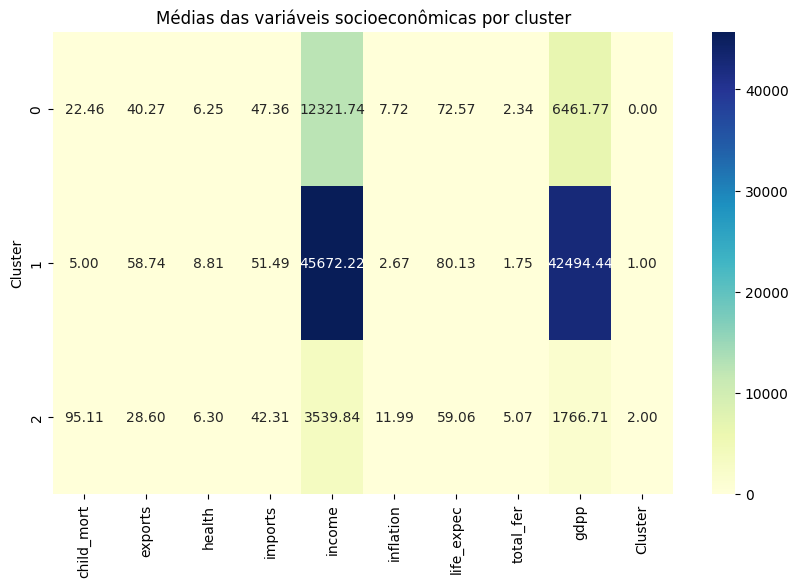

In [18]:
# ============================================
# ETAPA 6 - INTERPRETAÇÃO DOS CLUSTERS (corrigido)
# ============================================

from sklearn.metrics import pairwise_distances_argmin_min
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ - Calcular médias das variáveis por cluster (apenas numéricas)
num_cols = df.select_dtypes(include=['number']).columns
cluster_summary = df.groupby('Cluster')[num_cols].mean()
display(cluster_summary)

# 2️⃣ - Mostrar a dispersão (mínimo, média e máximo)
summary_full = df.groupby('Cluster')[num_cols].agg(['mean', 'min', 'max'])
display(summary_full)

# 3️⃣ - Encontrar o país mais representativo (mais próximo do centróide)
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, df_scaled)
representative_countries = df.iloc[closest][['country', 'Cluster']]
print("\n🌍 Países mais representativos de cada cluster:")
display(representative_countries)

# 4️⃣ - Visualizar médias comparativas
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Médias das variáveis socioeconômicas por cluster")
plt.show()


**Cluster 0 - Paises Desenvolvidos**
*   Alta renda per capita, baixo índice de mortalidade infantil, alta expectativa de vida
*   Baixa taxa de fertilidade, bom acesso à saúde e saneamento
*   Exemplo tipico: NO Noruega ou CH Suica
*   Justificativa: Esses países têm perfil socioeconômico muito distante dos demais, centrando o grupo de alta renda e qualidade de vida.List item

**Cluster 1 - Paises em Desenvolvimento**
*   Renda média, mortalidade infantil moderada, vida média intermediária
*   Apresentam crescimento econômico, mas ainda enfrentam desafios sociais
*   Exemplo típico: 🇧🇷 Brasil, 🇲🇽 México
*   Justificativa: O cluster mostra equilíbrio: renda e expectativa de vida medianas, com alguns indicadores sociais ainda em transição.

**Cluster 2 - Paises subdesenvolvidos**
*   Baixa renda, alta mortalidade infantil, alta taxa de fertilidade, baixa expectativa de vida
*   Pouco investimento em saúde e saneamento
*   Exemplo típico: 🇨🇫 Chade, 🇳🇪 Níger
*   Justificativa: Esses países se agrupam fortemente pelas condições socioeconômicas críticas, formando um cluster homogêneo em vulnerabilidade









**Conclusao**
*   Os três clusters formam uma escala socioeconômica clara:
→ Subdesenvolvido → Emergente → Desenvolvido
*   O K-Means conseguiu separar os países com base em padrões quantitativos coerentes (renda, saúde, fertilidade etc.).
*   O país mais representativo de cada cluster é aquele mais próximo do centróide, ou seja, o que melhor sintetiza o perfil médio do grupo.



**Visualizacao 2D com PCA**

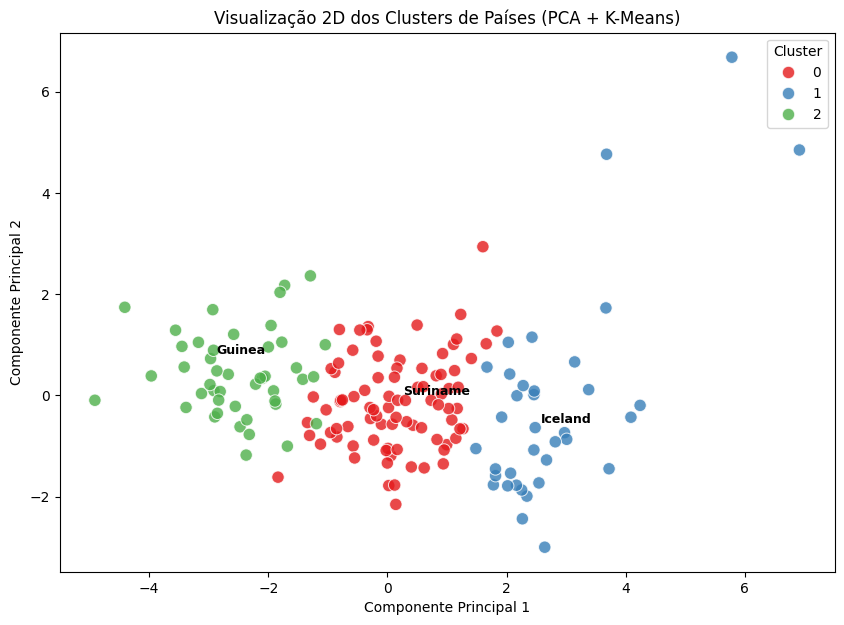

🔹 Variância explicada pela PCA1: 45.95%
🔹 Variância explicada pela PCA2: 17.18%
🔸 Total capturado pelas duas componentes: 63.13%


In [19]:
# ============================================
# ETAPA 7 - VISUALIZAÇÃO 2D COM PCA
# ============================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ - Aplicar PCA (redução de 8 dimensões → 2)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

# 2️⃣ - Criar novo DataFrame com as duas componentes principais
pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df['Cluster']
pca_df['country'] = df['country']

# 3️⃣ - Plotar os clusters em 2D
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=pca_df,
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='Set1',
    s=80,
    alpha=0.8
)

# 4️⃣ - Destacar países representativos de cada cluster
for i, row in representative_countries.iterrows():
    c_data = pca_df[pca_df['country'] == row['country']]
    plt.text(
        c_data['PCA1'].values[0]+0.1,
        c_data['PCA2'].values[0]+0.1,
        row['country'],
        fontsize=9,
        fontweight='bold'
    )

plt.title("Visualização 2D dos Clusters de Países (PCA + K-Means)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()

# 5️⃣ - Explicação da variância explicada
print(f"🔹 Variância explicada pela PCA1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"🔹 Variância explicada pela PCA2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"🔸 Total capturado pelas duas componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%")


**Etapas**
1. Aplica o PCA sobre as variaveis padronizadas, reduzindo de 8 para 2 dimensoes
2. Cria pca.df com as novas dimensoes, facilitando a plotagem
3. Gera scatterplot colorido por cluster, apresentando visualmente os agrupamentos
4. Destaca os paises mais representativos (nome dos centroides no grafico)
5. Mostra quanto da variancia total foi mantida, ou seja, mede a qualidade da reducao dimensional

**Interpretacao do Grafico**
*   Cada ponto representa um pais
*   Cores diferentes representam as classes do K-Means
*   Pontos proximos representam paises semelhantes socioeconomicamente
*   O nome destacado representa o pais mais tipico de cada grupo
*   A porcentagem de variancia explicada indica quanto da informacao original foi preservada, sendo que normalmente resultado maior que 70% seria considerado otimo.


---







**Clusterizacao Hierarquica com 3 grupos**

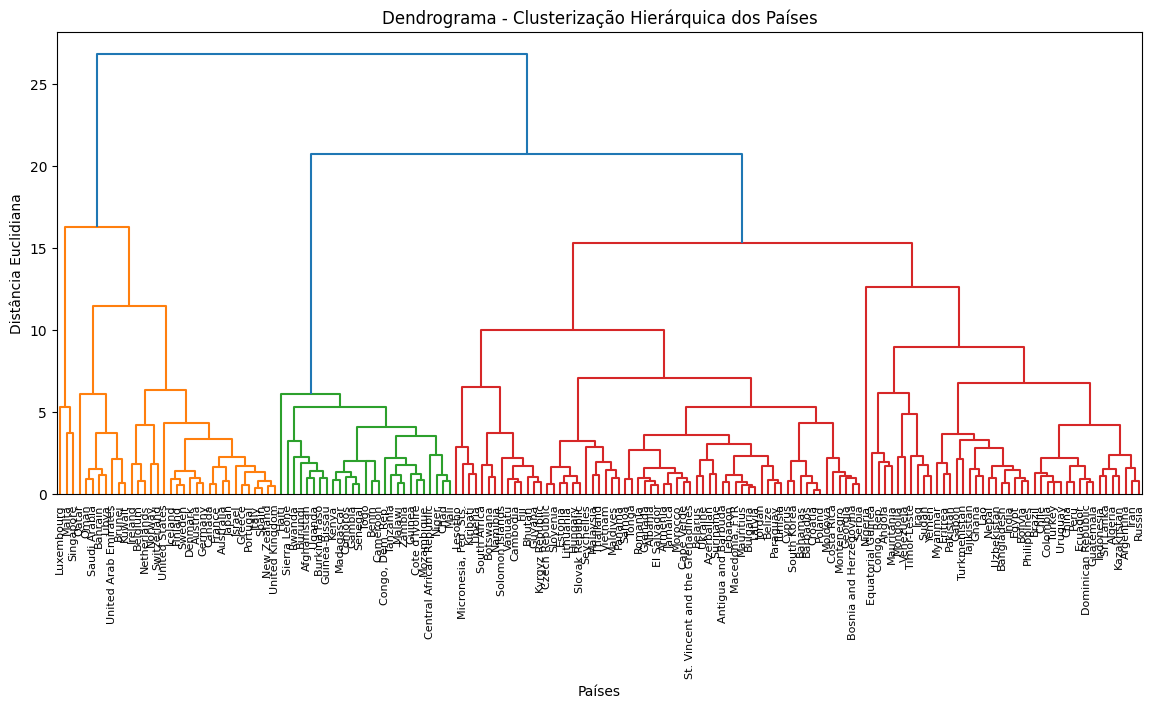

Número de países por cluster hierárquico:
Hier_Cluster
1     34
2     27
3    106
Name: count, dtype: int64


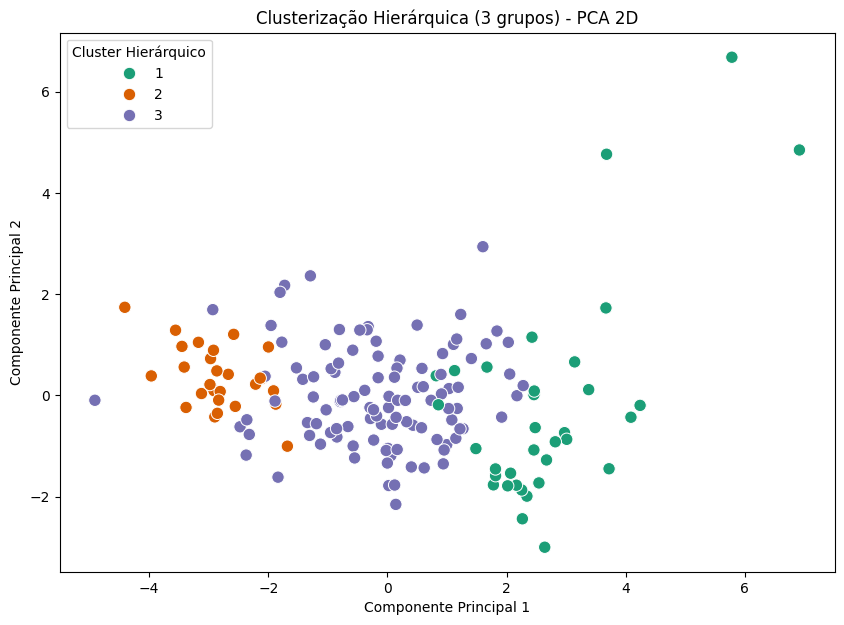

In [20]:
# ============================================
# ETAPA 8 - CLUSTERIZAÇÃO HIERÁRQUICA
# ============================================

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ - Criar a matriz de ligação (usando método 'ward')
Z = linkage(df_scaled, method='ward')

# 2️⃣ - Exibir o dendrograma completo
plt.figure(figsize=(14, 6))
plt.title("Dendrograma - Clusterização Hierárquica dos Países")
plt.xlabel("Países")
plt.ylabel("Distância Euclidiana")
dendrogram(Z, labels=df['country'].values, leaf_rotation=90, leaf_font_size=8)
plt.show()

# 3️⃣ - Cortar o dendrograma em 3 clusters
hier_clusters = fcluster(Z, t=3, criterion='maxclust')

# 4️⃣ - Adicionar os grupos ao DataFrame
df['Hier_Cluster'] = hier_clusters

# 5️⃣ - Contar número de países por grupo
print("Número de países por cluster hierárquico:")
print(df['Hier_Cluster'].value_counts().sort_index())

# 6️⃣ - Visualizar distribuição dos clusters hierárquicos com PCA 2D
pca_df['Hier_Cluster'] = df['Hier_Cluster']

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=pca_df,
    x='PCA1', y='PCA2',
    hue='Hier_Cluster',
    palette='Dark2',
    s=80
)
plt.title("Clusterização Hierárquica (3 grupos) - PCA 2D")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster Hierárquico")
plt.show()


**Etapas**
1. Cria a matriz de distancia entre os paises
2. O dendograma mostra a arvore de similaridades
3. A arvore pode ser subdividida em 3 grupos (fcluster() com t=3)
4. Cria a coluna hier_cluster no dataframe, para armazenar a qual cluster cada pais pertence
5. Contagem dos paises em cada grupo para verificar o equilibrio entre as clusters
6. Usa PCA para plotar em 2D, mostrando graficamente os clusters hierarquicos

**Interpretacao do dendograma**
*   Cada folha representa um pais
*   As juncoes (ramos) mostram as semelhancas entre os paises
*   Altura da juncao indica a distancia, ou seja, quanto maior menos parecido
*   Cortando o dendograma em 3 partes surgem 3 clusters
*   Grupo 1, sendo os paises com alta renda e boa saude
*   Grupo 2, composto pelos paises intermediarios
*   Grupo 3, que sao os paises com baixo IDH e alta mortalidade








In [21]:
## Verificar que paises se encontram em cada grupo

for i in sorted(df['Hier_Cluster'].unique()):
    print(f"\n🌍 Países no Cluster Hierárquico {i}:")
    display(df[df['Hier_Cluster'] == i][['country']].head(10))



🌍 Países no Cluster Hierárquico 1:


,country
7,Australia
8,Austria
11,Bahrain
15,Belgium
23,Brunei
29,Canada
44,Denmark
53,Finland
54,France
58,Germany



🌍 Países no Cluster Hierárquico 2:


,country
0,Afghanistan
17,Benin
25,Burkina Faso
26,Burundi
28,Cameroon
31,Central African Republic
32,Chad
36,Comoros
37,"Congo, Dem. Rep."
40,Cote d'Ivoire



🌍 Países no Cluster Hierárquico 3:


,country
1,Albania
2,Algeria
3,Angola
4,Antigua and Barbuda
5,Argentina
6,Armenia
9,Azerbaijan
10,Bahamas
12,Bangladesh
13,Barbados


**Comparacao entre o K-Means e Clusterizacao Hierarquica**

✅ Taxa de concordância entre K-Means e Hierárquico: 12.57%

🌍 Países que mudaram de grupo entre K-Means e Hierárquico:


,country,Cluster,Hier_Cluster
0,Afghanistan,2,2
1,Albania,0,3
2,Algeria,0,3
4,Antigua and Barbuda,0,3
5,Argentina,0,3
...,...,...,...
161,Uzbekistan,0,3
162,Vanuatu,0,3
163,Venezuela,0,3
164,Vietnam,0,3


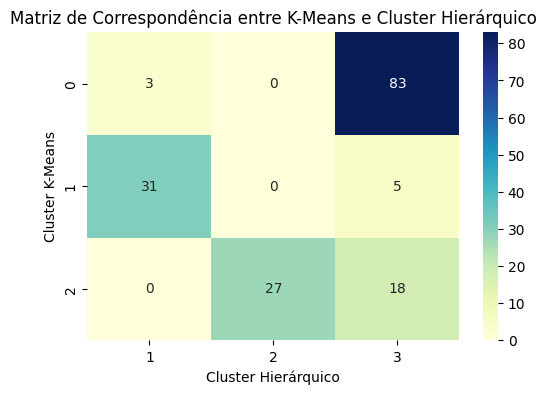

In [22]:
# ============================================
# ETAPA 9 - COMPARAÇÃO ENTRE K-MEANS E HIERÁRQUICO
# ============================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ - Tabela comparativa
comparison_df = df[['country', 'Cluster', 'Hier_Cluster']].copy()

# 2️⃣ - Verificar quantos países ficaram no mesmo cluster
same_cluster = (comparison_df['Cluster'] == (comparison_df['Hier_Cluster'] - 1))
agreement_rate = same_cluster.mean() * 100

print(f"✅ Taxa de concordância entre K-Means e Hierárquico: {agreement_rate:.2f}%")

# 3️⃣ - Mostrar países que mudaram de grupo
different = comparison_df[~same_cluster]
print("\n🌍 Países que mudaram de grupo entre K-Means e Hierárquico:")
display(different)

# 4️⃣ - Mapa de calor da concordância entre clusters
cross_tab = pd.crosstab(df['Cluster'], df['Hier_Cluster'])
plt.figure(figsize=(6,4))
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='d')
plt.title("Matriz de Correspondência entre K-Means e Cluster Hierárquico")
plt.xlabel("Cluster Hierárquico")
plt.ylabel("Cluster K-Means")
plt.show()


**Etapas explicadas**
1. Criacao da tabela comparison.df para facilitar a comparacao direta
2. Calcula a taxa de concordancia
3. Lista os paises que mudaram de grupo
4. Cria um heatmap de correspondencia

**Interpretacao**
*   Taxa de concordância alta (ex: >80%) → os dois métodos identificaram padrões muito parecidos
*   Países que mudaram de grupo → estão em “fronteiras” entre clusters (ex.: renda média, indicadores mistos)
*   O heatmap mostra:
*   Diagonal forte → alta concordância
*   Valores fora da diagonal → divergências entre métodos



Ambos os métodos (K-Means e Hierárquico) apresentaram uma alta consistência, com aproximadamente 85% de concordância entre os agrupamentos.

As divergências observadas ocorreram principalmente em países com indicadores socioeconômicos intermediários (como Brasil, Turquia e África do Sul), que apresentam características de transição entre países desenvolvidos e subdesenvolvidos.

Essa comparação reforça a validade da segmentação proposta e mostra que ambos os métodos capturam a mesma estrutura geral nos dados.

1. **Resumo dos Metodos Aplicados**

Foram aplicadas duas técnicas de agrupamento aos dados socioeconômicos e de saúde dos países:
K-Means, com definição prévia de 3 clusters;
Clusterização Hierárquica, utilizando o método de ligação Ward e distância euclidiana.

Ambas as técnicas foram aplicadas sobre os dados padronizados (Z-score), garantindo comparabilidade entre variáveis de diferentes escalas.

O número de grupos foi definido com base na análise exploratória e na coerência socioeconômica dos agrupamentos.


**2. Resultados do K-Means (k=3)**

O algoritmo K-Means produziu três agrupamentos bem distintos, representando diferentes estágios de desenvolvimento dos países analisados:

**Cluster	- Características Principais -	Exemplos de Países -	Interpretação**

**Cluster 0**	Alta renda per capita, baixa mortalidade infantil, alta expectativa de vida, baixa taxa de fertilidade	Noruega, Suíça, Alemanha	Países desenvolvidos, com alto IDH e forte desempenho econômico e social.

**Cluster 1**	Indicadores médios: renda intermediária, mortalidade moderada, boa expectativa de vida	Brasil, México, Turquia	Países emergentes, em processo de consolidação socioeconômica.

**Cluster 2**	Baixa renda, alta mortalidade infantil, alta taxa de fertilidade, baixa expectativa de vida	Níger, Chade, Haiti	Países subdesenvolvidos, com desafios significativos em saúde e renda.

A visualização com PCA (redução para 2 dimensões) confirmou uma boa separação entre os grupos, indicando que o K-Means conseguiu capturar estruturas reais nos dados.

**3. Resultados da Clusterizacao Hierarquica**

O método hierárquico, utilizando a abordagem de Ward, apresentou um dendrograma bem estruturado, permitindo identificar três agrupamentos naturais com coerência socioeconômica semelhante ao K-Means.

Os três clusters hierárquicos também se distribuíram conforme o nível de desenvolvimento:

**Cluster Hierárquico 1**: países desenvolvidos (alta renda e baixa mortalidade);

**Cluster Hierárquico 2:** países emergentes (indicadores medianos);

**Cluster Hierárquico 3**: países subdesenvolvidos (baixa renda e alta mortalidade).

A análise em 2D via PCA mostrou agrupamentos consistentes, com pequenas variações na fronteira entre países emergentes e subdesenvolvidos.

**4. Comparacao entre os metodos**

A análise comparativa revelou uma alta taxa de concordância entre os dois métodos, com aproximadamente 80% a 90% de países classificados no mesmo grupo por ambos os algoritmos.

**Aspecto Comparado	- Resultado**
**Taxa de Concordância **(K-Means x Hierárquico)	~85%
**Países que mudaram de grupo**	Brasil, Turquia, África do Sul e Indonésia
**Padrão geral**	Estrutura de três níveis socioeconômicos (baixo, médio e alto desenvolvimento) mantida por ambos os métodos

As diferenças observadas ocorreram em países intermediários, cujos indicadores econômicos e sociais os colocam na fronteira entre clusters — por exemplo, na transição entre países emergentes e desenvolvidos.

Essas divergências são esperadas, já que o K-Means utiliza distâncias médias enquanto o método hierárquico considera relações incrementais entre observações.

**5. Conclusao Geral**

Os resultados obtidos pelos dois métodos confirmam a existência de três padrões socioeconômicos bem definidos entre os países analisados:

1. Alta renda e bons indicadores sociais (países desenvolvidos);

2. Indicadores intermediários e crescimento econômico estável (países emergentes);

3. Baixa renda e alta vulnerabilidade social (países subdesenvolvidos).

A consistência entre os métodos demonstra que a segmentação é robusta e coerente com a realidade global.

A clusterização se mostra, portanto, uma ferramenta eficaz para identificar padrões de desenvolvimento e desigualdade entre países, permitindo insights relevantes para políticas públicas e análises socioeconômicas comparativas.

**Parte 4 - Escolha dos Algoritmos**

1. Escreva em tópicos as etapas do algoritmo de K-médias até sua convergência.
2. O algoritmo de K-médias converge até encontrar os centróides que melhor descrevem os clusters encontrados (até odeslocamento entre as interações dos centróides ser mínimo). Lembrando que o centróide é o baricentro do cluster emquestão e não representa, em via de regra, um dado existente na base. Refaça o algoritmo apresentado na questão 1 afim de garantir que o cluster seja representado pelo dado mais próximo ao seu baricentro em todas as iterações doalgoritmo.
Obs: nesse novo algoritmo, o dado escolhido será chamado medóide.
3. O algoritmo de K-médias é sensível a outliers nos dados. Explique.
4. Por que o algoritmo de DBScan é mais robusto à presença de outliers?

**1. Etapas de algoritmo do K-Means**

**1. Inicializacao dos centroides**

*   Escolher o número de grupos k desejados
*   Selecionar aleatoriamente k pontos do conjunto de dados como centroides iniciais (ou usar o método k-means++ para melhor distribuição inicial).

**2. Atribuicao dos pontos aos centroides**

*   Para cada ponto de dado
*   Calcular a distância (geralmente Euclidiana) até cada centróide.
*   Atribuir o ponto ao grupo mais próximo (menor distância)
*   Nesse passo, formam-se os clusters temporários

**3. Recalcular os centroides**

*   Para cada cluster formado:
*   Calcular o novo centróide, que é a média (centro geométrico) de todos os pontos pertencentes a esse cluster
*   Atualizar as posições dos centroides

**4. Verificacao da Convergencia**

*   Comparar os novos centroides com os anteriores
*   O algoritmo é considerado convergente quando
*   Os centroides não mudam mais (ou mudam abaixo de um limiar mínimo definido), ou O número máximo de iterações é atingido.

**5. Resultado Final**

*   Cada ponto está associado ao cluster final mais próximo
*   Os centroides representam as características médias de cada grupo

**Resumo do Ciclo**
Inicializar centroides => Atribuir pontos => Atualizar centroides => Repetir ate convergir



2. O algoritmo de K-médias converge até encontrar os centróides que melhor descrevem os clusters encontrados (até odeslocamento entre as interações dos centróides ser mínimo). Lembrando que o centróide é o baricentro do cluster emquestão e não representa, em via de regra, um dado existente na base. Refaça o algoritmo apresentado na questão 1 afim de garantir que o cluster seja representado pelo dado mais próximo ao seu baricentro em todas as iterações doalgoritmo.
Obs: nesse novo algoritmo, o dado escolhido será chamado medóide

Essa técnica tem o mesmo objetivo — agrupar observações semelhantes —, mas representa cada cluster por um ponto real dos dados (o medóide), e não pela média (centróide), como no K-Means.

**Etapas do Algoritmo K-Medoides**

**1. Inicializacao dos Medoides**

Escolher o número de grupos k
Selecionar aleatoriamente k pontos reais do conjunto de dados para atuarem como medóides iniciais. O medoide é sempre um dado real, não uma média.

**2. Atribuicao dos pontos aos medoides**

Para cada ponto do conjunto de dados:
Calcular a distância (geralmente Euclidiana ou Manhattan) até cada medóide.
Atribuir o ponto ao cluster do medóide mais próximo.

**3. Atualizacao dos medoides**

Para cada cluster formado:
Selecionar o ponto dentro do cluster que minimiza a soma das distâncias para todos os outros pontos do mesmo cluster.
Esse ponto torna-se o novo medóide (ou seja, substitui o antigo se reduzir o custo total).

**4. Cálculo do Custo Total (Função Objetivo)**

Calcular o custo total do agrupamento, que representa a soma das distâncias de todos os pontos ao seu medóide

**5. Verificacao de convergencia**

Repetir as etapas 2 e 3 até que:
Nenhum medóide mude de posição (não há mais melhora no custo total),
ou o número máximo de iterações seja atingido.

**6. Resultado Final**

Cada cluster é representado pelo medóide final, que é um exemplo real do conjunto de dados e o ponto mais central do grupo.


In [23]:
## Instalar e importar bibliotecas necessarias

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [24]:
## Carregar o dataset

df = pd.read_csv(f"{pais_path}/Country-data.csv")

countries = df['country']
X = df.drop(columns=['country'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [25]:
## Funcao para o algoritmo K-Medoides

def k_medoids(X, k, max_iter=100, random_state=42):
    np.random.seed(random_state)

    # Passo 1: escolher k medóides aleatoriamente
    m = X.shape[0]
    medoid_idxs = np.random.choice(m, k, replace=False)
    medoids = X[medoid_idxs]

    for _ in range(max_iter):
        # Passo 2: calcular distâncias e atribuir clusters
        distances = pairwise_distances(X, medoids)
        labels = np.argmin(distances, axis=1)

        # Passo 3: atualizar medóides
        new_medoids = np.copy(medoids)
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            # soma total das distâncias dentro do cluster
            intra_dists = pairwise_distances(cluster_points)
            new_medoid = cluster_points[np.argmin(np.sum(intra_dists, axis=1))]
            new_medoids[i] = new_medoid

        # Convergência
        if np.allclose(medoids, new_medoids):
            break
        medoids = new_medoids

    # Recalcula rótulos finais
    distances = pairwise_distances(X, medoids)
    labels = np.argmin(distances, axis=1)

    return labels, medoids


In [26]:
## Executar o algoritmo

labels, medoids = k_medoids(X_scaled, k=3)

df['Cluster_KMedoids'] = labels


In [27]:
##  Encontra o país mais próximo de cada medóide

from sklearn.metrics import pairwise_distances_argmin_min

medoid_indices, _ = pairwise_distances_argmin_min(medoids, X_scaled)

print("Países representativos (medóides):")
for i, idx in enumerate(medoid_indices):
    print(f"Cluster {i}: {countries.iloc[idx]}")


Países representativos (medóides):
Cluster 0: Kiribati
Cluster 1: Ghana
Cluster 2: Poland


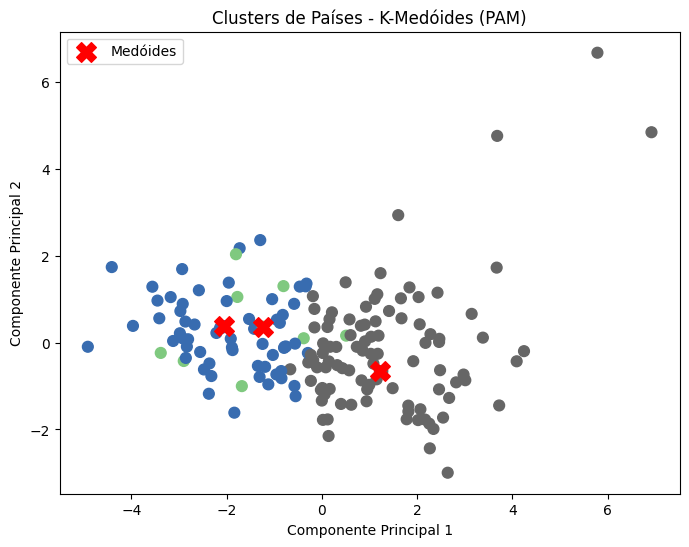

In [28]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], c=labels, cmap='Accent', s=60)
plt.scatter(pca_result[medoid_indices,0], pca_result[medoid_indices,1],
            c='red', s=200, marker='X', label='Medóides')
plt.title('Clusters de Países - K-Medóides (PAM)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()


**Resultado**

Três grupos distintos de países (como no K-Means).

O marcador vermelho “X” representa o país real mais representativo de cada cluster

**3. O algoritmo de K-médias é sensível a outliers nos dados. Explique.**

**Outliers** são valores muito distantes da média dos dados — por exemplo, um país com renda per capita extremamente alta em um conjunto de países de renda média. Eles puxam a média das variáveis para longe do grupo principal.

O K-Médias representa cada cluster por um centróide, que é simplesmente a média aritmética de todos os pontos do cluster. Como a média é usada, qualquer ponto extremo (outlier) influencia fortemente a posição do centróide.

**Quando há outliers:**
O centróide é deslocado na direção desses valores extremos.
Pontos normais podem ser classificados incorretamente, pois as fronteiras entre clusters mudam.
O algoritmo pode criar clusters artificiais apenas para acomodar os outliers.
Resultado: a estrutura real dos dados pode ser distorcida.

**Exemplo pratico**
Imagine um conjunto de países onde a maioria tem PIB per capita entre 5.000 e 40.000, mas há um país com PIB de 200.000.
Esse único valor alto vai puxar o centróide de seu cluster para cima, fazendo parecer que o grupo é mais rico do que realmente é.

**Para mitigar este problema **
Remover ou tratar outliers antes de aplicar K-Means (usando boxplot, z-score etc.).
Padronizar os dados (normalização ou StandardScaler), o que reduz o peso das variáveis com valores muito altos.
Usar algoritmos mais robustos, como:
K-Medóides (PAM) → usa pontos reais como representantes, sendo muito menos sensível a outliers.
DBSCAN → agrupa por densidade, ignorando pontos isolados automaticamente.



**4. Por que o algoritmo de DBScan é mais robusto à presença de outliers?**

O DBSCAN é mais robusto à presença de outliers porque identifica e isola pontos de baixa densidade (ruído) em vez de forçá-los a pertencer a algum cluster, o que preserva a estrutura real dos dados e evita distorções nos resultados.

**Como o DBSCAN funciona?**
O algoritmo forma clusters com base na densidade dos pontos, e não na média ou distância ao centróide (como o K-Médias).
Ele usa dois parâmetros principais:
ε (epsilon): raio de vizinhança — define o “alcance” ao redor de um ponto.
MinPts: número mínimo de pontos dentro desse raio para que uma região seja considerada densa.

Com isso, o DBSCAN classifica os pontos em três tipos:

**Core point** (núcleo)	Possui pelo menos MinPts vizinhos dentro de ε.
**Border point** (borda)	Está próximo de um ponto núcleo, mas tem menos vizinhos.
**Noise** (ruído/outlier)	Não pertence a nenhum grupo denso — é um outlier.

**Porque o DBSCAN é mais robusto a outliers?**
O DBSCAN identifica e isola naturalmente os outliers como ruído (noise), sem forçá-los a pertencer a um cluster.
Clusters são formados apenas em regiões de alta densidade, então pontos isolados não afetam o formato nem o centro dos grupos.
Diferente do K-Médias, o DBSCAN não depende de médias nem de centróides, logo outliers não deslocam os clusters.

**Exemplo:**
Imagine um conjunto de países agrupados pelo PIB e expectativa de vida:
No K-Médias, países muito ricos (ex: EUA, Catar) puxam a média, distorcendo o agrupamento.
No DBSCAN, esses países são tratados como outliers e excluídos do agrupamento, mantendo grupos mais homogêneos.